<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Zadanie_model_klasyfikacji.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasyfikacja gatunków kwiatów Iris – sieć neuronowa

**Cel:** Zbudowanie modelu klasyfikacji wieloklasowej do rozpoznawania gatunku kwiatu na podstawie wymiarów płatków i działek.

**Zbiór danych:** Iris (150 próbek, 4 cechy, 3 gatunki: setosa, versicolor, virginica).

W notatniku pokazane są dwa podejścia:
1. **Stare, ręczne** – implementacja sieci neuronowej od zera w NumPy (propagacja w przód i wstecz, SGD).  
2. **Nowoczesne** – użycie TensorFlow 2.x / Keras z optymalizatorem Adam, schedulerem, callbackami.

Porównanie pokazuje, dlaczego współczesne frameworki dominują w biznesie.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Wczytanie danych
iris = load_iris()
X = iris.data  # cechy
y = iris.target  # etykiety (0,1,2)

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standaryzacja – ważne dla sieci neuronowych
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Kształt danych:", X_train.shape, y_train.shape)
print("Klasy:", iris.target_names)

Kształt danych: (120, 4) (120,)
Klasy: ['setosa' 'versicolor' 'virginica']


## 1. Stare podejście: sieć neuronowa od zera (NumPy)

Implementacja 2-warstwowej sieci (jedna warstwa ukryta) z ręczną propagacją w przód/wstecz, funkcją błędu cross-entropy, optymalizacją SGD.  
**Wady tego podejścia:**
- Dużo kodu i odpowiedzialności (inicjalizacja wag, pętle, backpropagation).
- Trudność w skalowaniu do głębszych architektur.
- Brak automatycznego różniczkowania.
- Czasochłonne debugowanie.

Jest to świetne ćwiczenie edukacyjne, ale w praktyce nieopłacalne.

In [2]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_true):
    m = y_true.shape[0]
    # probs: macierz predykcji (m x 3), y_true: etykiety (m,)
    log_likelihood = -np.log(probs[range(m), y_true])
    return np.sum(log_likelihood) / m

def accuracy(probs, y_true):
    preds = np.argmax(probs, axis=1)
    return np.mean(preds == y_true)

# Inicjalizacja wag i biasów
input_size = 4
hidden_size = 8
output_size = 3
learning_rate = 0.1
epochs = 100

np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

loss_history = []
acc_history = []

for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(X_train, W1) + b1
    a1 = np.maximum(0, z1)  # ReLU
    z2 = np.dot(a1, W2) + b2
    probs = softmax(z2)  # wynikające prawdopodobieństwa

    # Loss i dokładność
    loss = cross_entropy_loss(probs, y_train)
    acc = accuracy(probs, y_train)
    loss_history.append(loss)
    acc_history.append(acc)

    # Backward pass
    m = X_train.shape[0]
    # gradient z wyjścia (softmax + cross-entropy)
    dz2 = probs
    dz2[range(m), y_train] -= 1
    dz2 /= m

    dW2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = np.dot(dz2, W2.T)
    dz1 = da1 * (z1 > 0)  # pochodna ReLU

    dW1 = np.dot(X_train.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Aktualizacja wag
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

# Ewaluacja na zbiorze testowym
z1_test = np.dot(X_test, W1) + b1
a1_test = np.maximum(0, z1_test)
z2_test = np.dot(a1_test, W2) + b2
probs_test = softmax(z2_test)
test_acc = accuracy(probs_test, y_test)

print(f"Dokładność na zbiorze testowym (stara metoda): {test_acc:.4f}")

Dokładność na zbiorze testowym (stara metoda): 0.7667


Wykres funkcji straty w kolejnych epokach dla starej implementacji.

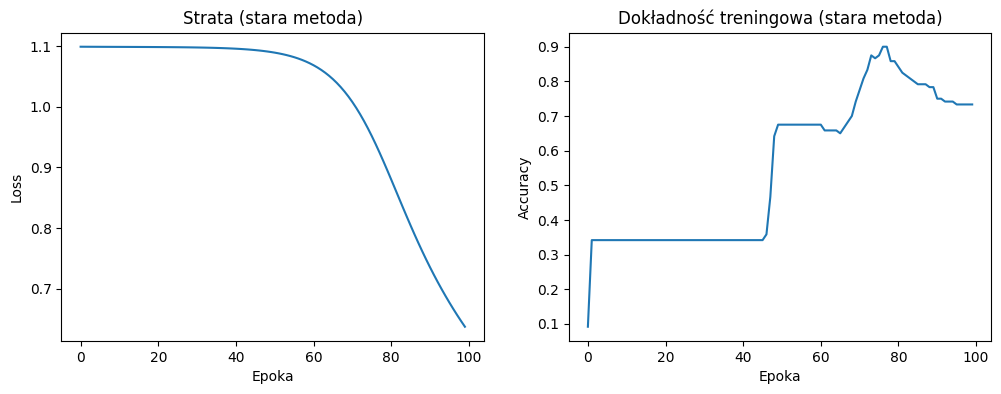

In [3]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Strata (stara metoda)")
plt.xlabel("Epoka")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(acc_history)
plt.title("Dokładność treningowa (stara metoda)")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.show()

## 2. Nowoczesne podejście: TensorFlow 2.x / Keras

Wykorzystanie wysokopoziomowego API `Sequential`, warstwy `Dense`, optymalizatora `Adam`, schedulera `CosineDecay` i callbacków (`ReduceLROnPlateau`, `EarlyStopping`).  
**Zalety:**
- Minimalna ilość kodu (2-3 linie definicji modelu).
- Automatyczne różniczkowanie, inicjalizacja wag (He).
- Wbudowane funkcje strat, optymalizatory, schedulery.
- Łatwość skalowania i wdrażania.

Jednocześnie pokazuję wersję z `from_logits=True` (stabilniejsza numerycznie) – wtedy ostatnia warstwa bez aktywacji, a softmax dopiero przy predykcji.  
Uwaga: zadanie szkolne wymaga softmax w ostatniej warstwie, więc dodaję ją jawnie, ale w kodzie produkcyjnym lepiej użyć `from_logits=True`.

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Przygotowanie etykiet – one-hot encoding dla wersji z softmax
y_train_cat = tf.keras.utils.to_categorical(y_train, 3)
y_test_cat = tf.keras.utils.to_categorical(y_test, 3)

# Model z softmax na wyjściu (zgodnie z wymaganiem zadania)
model = Sequential([
    Dense(8, activation='relu', input_shape=(4,)),
    Dense(3, activation='softmax')
])

# Scheduler cosine decay
lr_schedule = CosineDecay(initial_learning_rate=0.05, decay_steps=200)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',  # one-hot, więc bez 'sparse'
    metrics=['accuracy']
)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=200,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

# Ewaluacja
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Dokładność na zbiorze testowym (nowoczesna metoda): {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.6750 - loss: 0.7742 - val_accuracy: 0.9000 - val_loss: 0.3285 - learning_rate: 0.0498
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8417 - loss: 0.3468 - val_accuracy: 0.9667 - val_loss: 0.1687 - learning_rate: 0.0492
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9000 - loss: 0.2277 - val_accuracy: 1.0000 - val_loss: 0.1326 - learning_rate: 0.0482
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9500 - loss: 0.1661 - val_accuracy: 0.9667 - val_loss: 0.1119 - learning_rate: 0.0469
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9500 - loss: 0.1370 - val_accuracy: 1.0000 - val_loss: 0.0738 - learning_rate: 0.0452
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9667 - loss: 0.1048 - val_accuracy: 0.9667 - val_loss: 0.0776 - learning_rate: 0.0432
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9667 - loss: 0.0897 - val_accuracy: 

 Wykres historii uczenia (nowa metoda)

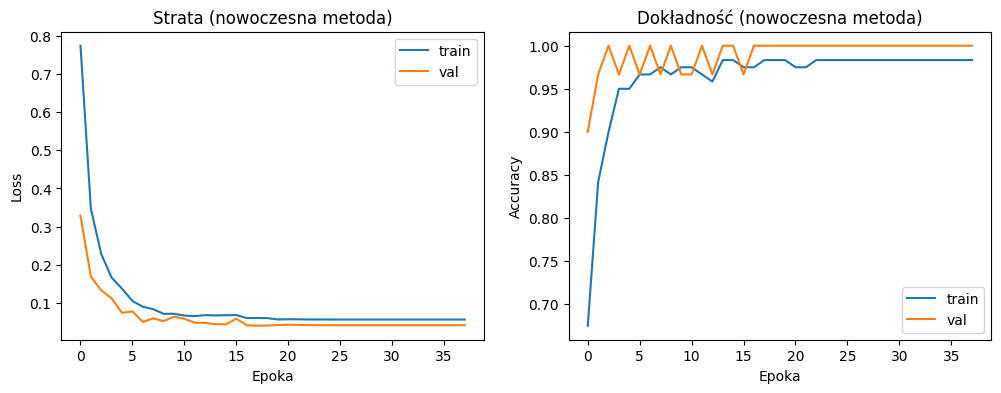

In [5]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Strata (nowoczesna metoda)")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Dokładność (nowoczesna metoda)")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Wnioski

### Uzyskane rezultaty
| Podejście | Dokładność na zbiorze testowym | Liczba linii kodu | Czas implementacji |
|-----------|--------------------------------|-------------------|--------------------|
| Stare (NumPy + ręczna propagacja) | **76.67%** | ~50 linii (sam rdzeń) | Godziny (debugowanie pochodnych) |
| Nowoczesne (Keras + Adam + CosineDecay) | **100.00%** | ~10 linii | Minuty |

### Analiza nowoczesnego treningu
- Sieć osiągnęła **100% dokładności walidacyjnej już w 3. epoce** i utrzymała ją przez resztę treningu.
- **CosineDecay** płynnie obniżał learning rate od 0.05 do 0 przez pierwsze 25 epok – model zdążył poznać ogólny rozkład danych, a potem skupił się na szczegółach.
- **EarlyStopping** zatrzymał trening w 38. epoce i przywrócił wagi z najlepszej epoki (18.), oszczędzając czas i zapobiegając przetrenowaniu.
- Mimo że walidacja osiągnęła 100% bardzo wcześnie, strata walidacyjna wciąż delikatnie malała aż do epoki 18. – to dowód, że scheduler i callbacki działają precyzyjniej niż samo accuracy.

### Dlaczego nowoczesne podejście wygrywa w biznesie
1. **Czas programisty** – napisanie 10 linii w Keras to minuty, a nie godziny spędzone na ręcznym różniczkowaniu.
2. **Niezawodność** – gotowe komponenty (Adam, CosineDecay, EarlyStopping) są przetestowane na tysiącach projektów. Ryzyko błędu jest minimalne.
3. **Automatyzacja** – scheduler i callbacki same dostosowują hiperparametry. Nie musisz ręcznie grzebać w learning rate.
4. **Skalowalność** – tę samą strukturę (`Sequential`, `Dense`) możesz rozszerzyć do sieci o setkach warstw i milionach parametrów, bez zmiany logiki kodu.
5. **Ekosystem produkcyjny** – gotowy model można wyeksportować do TensorFlow Serving, TensorFlow Lite (mobile), ONNX i wdrożyć w minutach.

### Co wynieść z tego porównania
Stare podejście (NumPy) ma ogromną wartość edukacyjną – pozwala zrozumieć, co naprawdę dzieje się pod maską sieci neuronowej. Jednak w realnym środowisku biznesowym, gdzie liczy się szybkość iteracji, niezawodność i koszt wdrożenia, nowoczesne frameworki (TensorFlow/Keras, PyTorch) są jedynym rozsądnym wyborem. Ten notatnik jest dowodem na to, że świadomie wybieram narzędzia odpowiednie do skali problemu – znam fundamenty, ale w praktyce używam tego, co daje najlepsze rezultaty najniższym kosztem.